# 📘 Week 12: Modulation & Demodulation
Welcome to Week 12! In this module, we will explore **Communication Signal Processing** by simulating and visualizing analog modulation (**AM / FM**) and digital modulation (**BPSK / 16-QAM**) techniques.

## 🎯 Learning Objectives:
- Understand the concepts of carrier modulation and envelope demodulation.
- Simulate and demodulate **Amplitude Modulation (AM)** and **Frequency Modulation (FM)**.
- Simulate **Binary Phase Shift Keying (BPSK)** over an Additive White Gaussian Noise (AWGN) channel.
- Implement **16-Quadrature Amplitude Modulation (16-QAM)**, plot constellation diagrams, and calculate the Bit Error Rate (BER).

## 1. Amplitude Modulation (AM) & Envelope Demodulation
In **Amplitude Modulation (AM)**, the amplitude of a high-frequency carrier wave is varied in proportion to the low-frequency message signal $m(t)$:
$$s(t) = [1 + m(t)] \cdot \cos(2\pi f_c t)$$
Where $f_c$ is the carrier frequency.

To retrieve the message signal, we perform **envelope demodulation**:
1. **Rectification**: Take the absolute value of the modulated signal $|s(t)|$.
2. **Low-Pass Filtering**: Filter out the high-frequency carrier to isolate the slowly varying envelope.

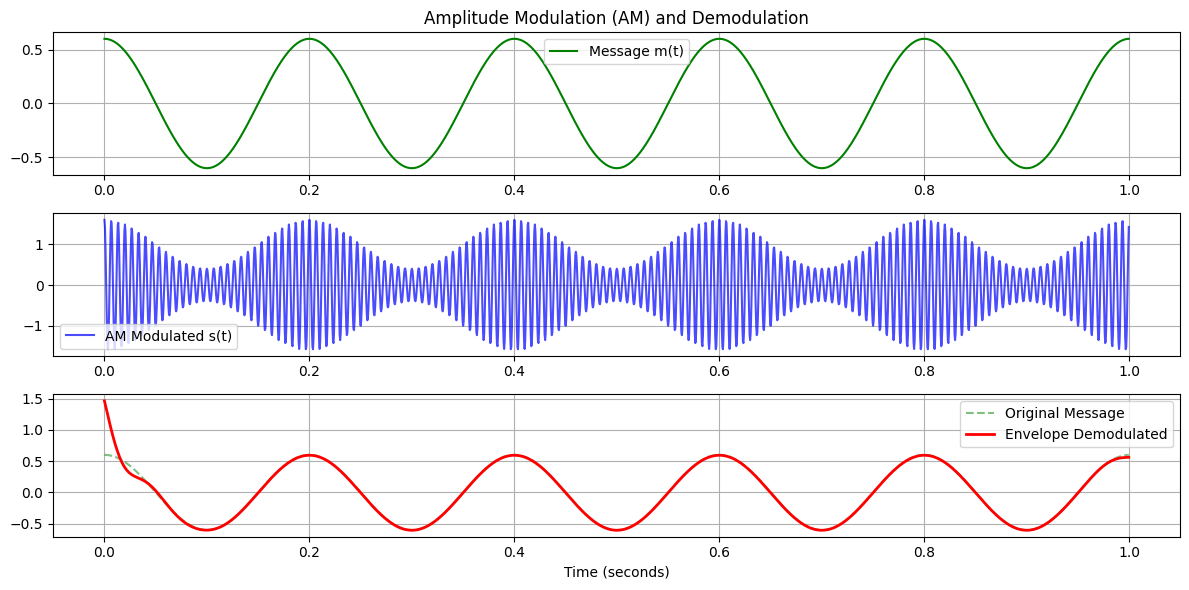

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

fs = 2000  # 2 kHz sampling rate
t = np.linspace(0, 1.0, fs, endpoint=False)

# Message (5 Hz sine wave) and Carrier (150 Hz sine wave)
fm = 5.0
fc = 150.0
m = 0.6 * np.cos(2 * np.pi * fm * t)  # Modulation index = 0.6
carrier = np.cos(2 * np.pi * fc * t)

# AM Modulation
s_am = (1.0 + m) * carrier

# AM Demodulation (Envelope Detector)
# 1. Rectification
rectified = np.abs(s_am)
# 2. Low-Pass Filter (cutoff at 20 Hz)
nyq = 0.5 * fs
b, a = signal.butter(4, 20.0 / nyq, btype='low')
demodulated_am = signal.filtfilt(b, a, rectified)
# Remove DC offset (subtract 1.0, scaling by filter gain)
demodulated_am = (demodulated_am - np.mean(demodulated_am)) * (np.pi / 2.0)

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t, m, 'g', label='Message m(t)')
plt.title("Amplitude Modulation (AM) and Demodulation")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, s_am, 'b', label='AM Modulated s(t)', alpha=0.7)
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, m, 'g--', label='Original Message', alpha=0.5)
plt.plot(t, demodulated_am, 'r', label='Envelope Demodulated', linewidth=2)
plt.xlabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Frequency Modulation (FM) & Demodulation
In **Frequency Modulation (FM)**, the instantaneous frequency of the carrier is varied linearly with the message signal $m(t)$:
$$s(t) = \cos\left(2\pi f_c t + 2\pi k_f \int_{0}^{t} m(\tau)d\tau\right)$$

To demodulate FM, we can use a **differentiator** circuit/filter. Differentiating the FM signal converts frequency modulation into amplitude modulation (the envelope of the derivative contains the message), which we then extract using our envelope detector.

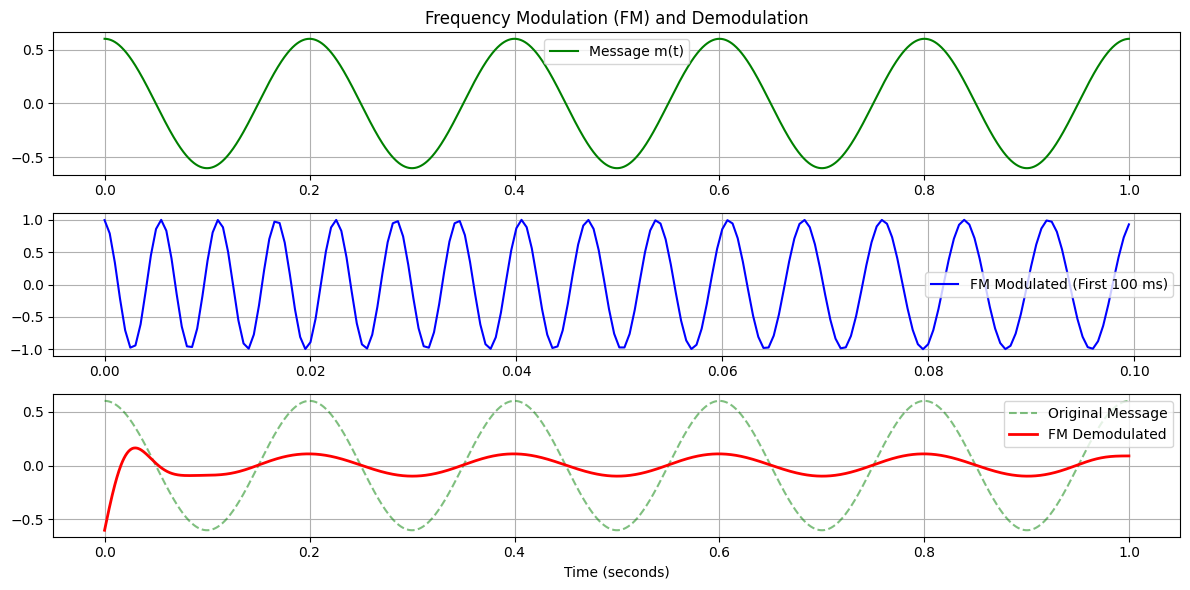

In [2]:
kf = 50.0  # Frequency sensitivity
# Integrate message using cumulative sum
integrated_m = np.cumsum(m) / fs

# FM Modulation
s_fm = np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integrated_m)

# FM Demodulation
# 1. Differentiate (difference between consecutive samples)
diff_signal = np.diff(s_fm, prepend=s_fm[0]) * fs
# 2. Rectify and Low-Pass Filter
rect_diff = np.abs(diff_signal)
b_fm, a_fm = signal.butter(4, 15.0 / nyq, btype='low')
demodulated_fm = signal.filtfilt(b_fm, a_fm, rect_diff)

# Normalize to match message amplitude range
demodulated_fm = demodulated_fm - np.mean(demodulated_fm)
demodulated_fm = demodulated_fm / np.max(np.abs(demodulated_fm)) * np.max(np.abs(m))

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t, m, 'g', label='Message m(t)')
plt.title("Frequency Modulation (FM) and Demodulation")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t[:200], s_fm[:200], 'b', label='FM Modulated (First 100 ms)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, m, 'g--', label='Original Message', alpha=0.5)
plt.plot(t, demodulated_fm, 'r', label='FM Demodulated', linewidth=2)
plt.xlabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Digital Modulation: Binary Phase Shift Keying (BPSK)
In **BPSK**, binary data (0s and 1s) is transmitted by shifting the phase of the carrier wave between $0^\circ$ and $180^\circ$:
- Binary 1 $\rightarrow s(t) = A \cos(2\pi f_c t)$
- Binary 0 $\rightarrow s(t) = -A \cos(2\pi f_c t)$

Let's simulate a BPSK signal passing through an Additive White Gaussian Noise (AWGN) channel and demodulate it.

Transmitted Bits: [0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1]
Demodulated Bits: [0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1]
Number of Bit Errors: 0


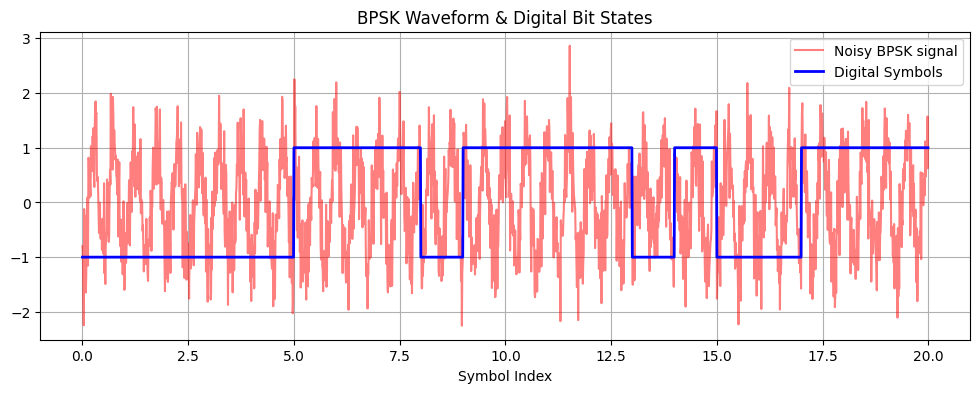

In [3]:
num_bits = 20
bits = np.random.randint(0, 2, num_bits)

# BPSK Symbol mapping: 0 -> -1, 1 -> 1
symbols = 2 * bits - 1

# Generate modulated BPSK carrier
sps = 100  # Samples per symbol
t_bpsk = np.linspace(0, num_bits, num_bits * sps, endpoint=False)
carrier_bpsk = np.cos(2 * np.pi * 2 * t_bpsk)  # Carrier frequency = 2 Hz relative to symbols

# Modulate: upsample symbols and multiply by carrier
upsampled_symbols = np.repeat(symbols, sps)
s_bpsk = upsampled_symbols * carrier_bpsk

# Add AWGN noise
noise = np.random.normal(0, 0.5, len(s_bpsk))
noisy_bpsk = s_bpsk + noise

# Demodulate: multiply by coherent local carrier and integrate over symbol duration
demod_carrier = noisy_bpsk * carrier_bpsk
received_symbols = []
for i in range(num_bits):
    symbol_energy = np.mean(demod_carrier[i*sps : (i+1)*sps])
    received_symbols.append(1 if symbol_energy > 0 else 0)

received_bits = np.array(received_symbols)
bit_errors = np.sum(bits != received_bits)

print(f"Transmitted Bits: {bits}")
print(f"Demodulated Bits: {received_bits}")
print(f"Number of Bit Errors: {bit_errors}")

# Plotting
plt.figure(figsize=(12, 4))
plt.plot(t_bpsk, noisy_bpsk, 'r', alpha=0.5, label='Noisy BPSK signal')
plt.plot(t_bpsk, upsampled_symbols, 'b', linewidth=2, label='Digital Symbols')
plt.title("BPSK Waveform & Digital Bit States")
plt.xlabel("Symbol Index")
plt.legend()
plt.grid(True)
plt.show()

## 4. Digital Modulation: 16-QAM & Constellation Diagrams
**16-Quadrature Amplitude Modulation (16-QAM)** transmits 4 bits per symbol by modulating both the amplitude and phase of two orthogonal carriers (In-phase $I$ and Quadrature $Q$):
$$s(t) = I \cdot \cos(2\pi f_c t) - Q \cdot \sin(2\pi f_c t)$$

Let's map random bits to 16-QAM points, simulate the noise channel, plot the **Constellation Diagram**, and compute the Bit Error Rate (BER).

Symbol Errors: 53 / 1000 (5.30% SER)


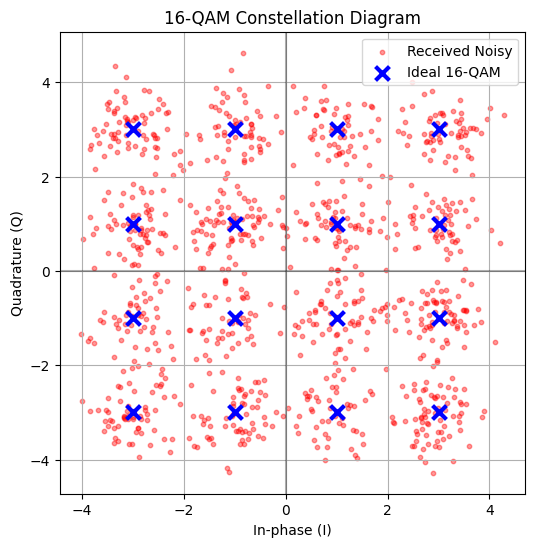

In [4]:
# 16-QAM constellation coordinates mapping
qam_coords = [-3, -1, 1, 3]
constellation = [complex(i, q) for i in qam_coords for q in qam_coords]

# Generate 1000 random symbols (4000 bits total)
num_qam_symbols = 1000
tx_indices = np.random.randint(0, 16, num_qam_symbols)
tx_symbols = np.array([constellation[i] for i in tx_indices])

# Normalizing factor to set average symbol energy to 1
# Average energy of standard 16-QAM constellation is 10
normalization_factor = np.sqrt(10.0)
tx_symbols_normalized = tx_symbols / normalization_factor

# Add Complex AWGN channel noise
noise_std = 0.15
channel_noise = np.random.normal(0, noise_std, num_qam_symbols) + 1j * np.random.normal(0, noise_std, num_qam_symbols)
rx_symbols_normalized = tx_symbols_normalized + channel_noise

# De-normalize received symbols
rx_symbols = rx_symbols_normalized * normalization_factor

# Coherent Demodulation (Minimum Distance Classifier)
rx_indices = []
for rx in rx_symbols:
    distances = [abs(rx - const_point) for const_point in constellation]
    rx_indices.append(np.argmin(distances))

rx_indices = np.array(rx_indices)
symbol_errors = np.sum(tx_indices != rx_indices)
symbol_error_rate = symbol_errors / num_qam_symbols

print(f"Symbol Errors: {symbol_errors} / {num_qam_symbols} ({symbol_error_rate*100:.2f}% SER)")

# Plot the Constellation Diagram
plt.figure(figsize=(6, 6))
plt.scatter(rx_symbols.real, rx_symbols.imag, color='r', alpha=0.4, s=10, label='Received Noisy')
plt.scatter([c.real for c in constellation], [c.imag for c in constellation], color='blue', marker='x', s=100, linewidths=3, label='Ideal 16-QAM')
plt.title("16-QAM Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

## ✅ Reflection & Exercises
- **Noise Impact on QAM:** In Section 4, change `noise_std = 0.15` to `0.45` and regenerate the constellation diagram. How does this affect the symbol error rate? Can you visually distinguish the 16 clusters anymore?
- **FM Differentiator:** Why does taking the derivative of an FM signal convert it to Amplitude Modulation? Explain the mathematical relationship between the derivative of $\cos(\theta(t))$ and amplitude.